# Quick walkthrough

This tutorial walks through the central methods and arguments to build workflows for depositing particle fields onto structured grids. 

+ We will see how to deposit weights of particles drawn from the swiss role dataset onto a uniform 2D grid.
+ We will use both `isotropic` and `covariant` structures for direct comparison.

In [144]:
import matplotlib.pyplot as plt
import numpy as np
import smudgy as sm

np.random.seed(0)

In [145]:
try:
    plt.style.use('custom')
except:
    pass
%matplotlib inline
%config InlineBackend.figure_format='retina'

## Depositing a scalar field onto a grid

We will use particles drawn from the swiss role dataset in an open box (i.e. no `boxsize` parameter is necessary) and weights set to ones:

In [146]:
# Swiss roll parameters
height = 1.0
length = 5 * np.pi
noise  = 1.0

N = 50_000

# Generate 2D Swiss roll dataset
t = length * (np.random.rand(N)) + 1.5 * np.pi  # t in [1.5pi, 3pi]
x = t * np.cos(t)
y = t * np.sin(t)

# Add noise
x += noise * np.random.randn(N)
y += noise * np.random.randn(N)

# Rescale to [0, 1]
X_swiss = np.vstack((x, y)).T
min_X = X_swiss.min(axis=0)
max_X = X_swiss.max(axis=0)
positions = (X_swiss - min_X) / (max_X - min_X + 1e-8)* 0.99

Let's inspect the particle distribution via a simple scatter plot:

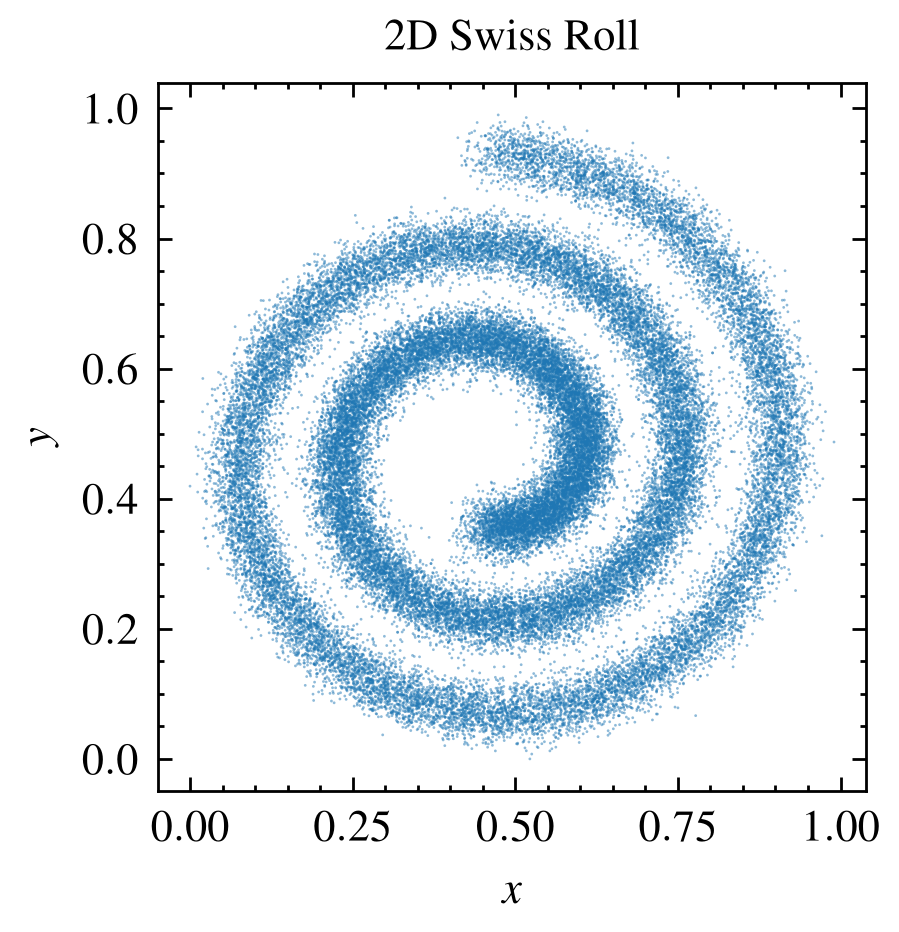

In [147]:
fig, ax = plt.subplots()
ax.scatter(positions[:, 0], positions[:, 1], edgecolors='none', s=1, alpha=0.5)
ax.set(xlabel=r'$x$', ylabel=r'$y$', aspect='equal')
ax.set_title('2D Swiss Roll')
plt.show(); plt.close()

Then, we initialize a {py:class}`~smudgy.pointcloud.PointCloud` instance and globally set the kernel to a cubic spline and the number of neighbors to use in computations to 512. The structure we do not fix for now as we want to use methods both with `isotropic` and `covariant` structures.

In [148]:
pc = sm.PointCloud(positions=positions).global_setup(kernel_name='lucy', num_neighbors=512)

[smudgy] Set taichi backend
[smudgy] Using 1 MPI rank
[smudgy] Initialized 2d PointCloud with 50000 particles without periodicity
[smudgy] Set kernel to 'lucy'
[smudgy] Set number of neighbors to 512


Next we compute the smoothing lengths and tensors, by passing the `isotropic` and `covariant` structure argument to the {py:meth}`~smudgy.pointcloud.PointCloud.compute_smoothing` method.

In [149]:
pc.compute_smoothing(structure='isotropic')
pc.compute_smoothing(structure='covariant')

pc.compute_density(structure='isotropic')
pc.compute_density(structure='covariant')

[smudgy] Building kd-tree from positions
[smudgy] Computing smoothing lengths from 512 neighbors
[smudgy] Computing smoothing tensors from 512 neighbors
[smudgy] Computing density using isotropic 'lucy' kernel
[smudgy] Computing density using covariant 'lucy' kernel


Since all smoothing information is stored in the `pc.smoothing` attribute, we can check individual fields:

In [150]:
print('Shape of smoothing lengths:', pc.smoothing.smoothing_lengths.shape)
print('Shape of smoothing tensors:', pc.smoothing.smoothing_tensors.shape)
print('Shape of smoothing tensor eigenvalues:', pc.smoothing.smoothing_tensors_eigvals.shape)
print('Shape of smoothing tensor eigenvectors:', pc.smoothing.smoothing_tensors_eigvecs.shape)

Shape of smoothing lengths: (50000,)
Shape of smoothing tensors: (50000, 2, 2)
Shape of smoothing tensor eigenvalues: (50000, 2)
Shape of smoothing tensor eigenvectors: (50000, 2, 2)


In [151]:
print(pc.smoothing.smoothing_lengths)
print(pc.smoothing.smoothing_tensors_eigvals)

[0.03882988 0.0395062  0.049099   ... 0.04579386 0.05456324 0.03400351]
[[0.0175415  0.02018262]
 [0.01707479 0.02035693]
 [0.02390847 0.02633894]
 ...
 [0.02072749 0.02662775]
 [0.0268666  0.02988704]
 [0.01513896 0.01690268]]


Next, let's deposit the densities onto a uniform 2D grid with 256 cells on each side. We perform this deposition once using `isotropic` and once `covariant` kernel structures. Note that, since energy is an additive quantitiy (just like e.g. mass), we set `averaged=False`. Since the point cloud lives in an open, non-periodic box (no `boxsize` parameter was given during initialization), we need to pass the `extent` over which the deposition grid should cover:

In [ ]:
nx = 128
extent = [[0, height], [0, height]]

grid_isotropic = pc.deposit(
    fields=np.ones_like(pc.weights),
    structure='isotropic',
    averaged=False,
    extent=extent,
    gridnums=nx,
    eta_crit=10,
    num_kernel_evaluations_per_axis=16
    )[0]

grid_covariant = pc.deposit(
    fields=np.ones_like(pc.weights),
    structure='covariant',
    averaged=False,
    extent=extent,
    gridnums=nx,
    eta_crit=10,
    num_kernel_evaluations_per_axis=16
    )[0]

[smudgy] Depositing using isotropic 'lucy' kernel
[smudgy] Depositing using covariant 'lucy' kernel


Let's visualize the deposited values for both structures as well as the relative difference between the two results. For better visualization, we transform the fields to log-space and compute the relative difference based on the transformed fields:

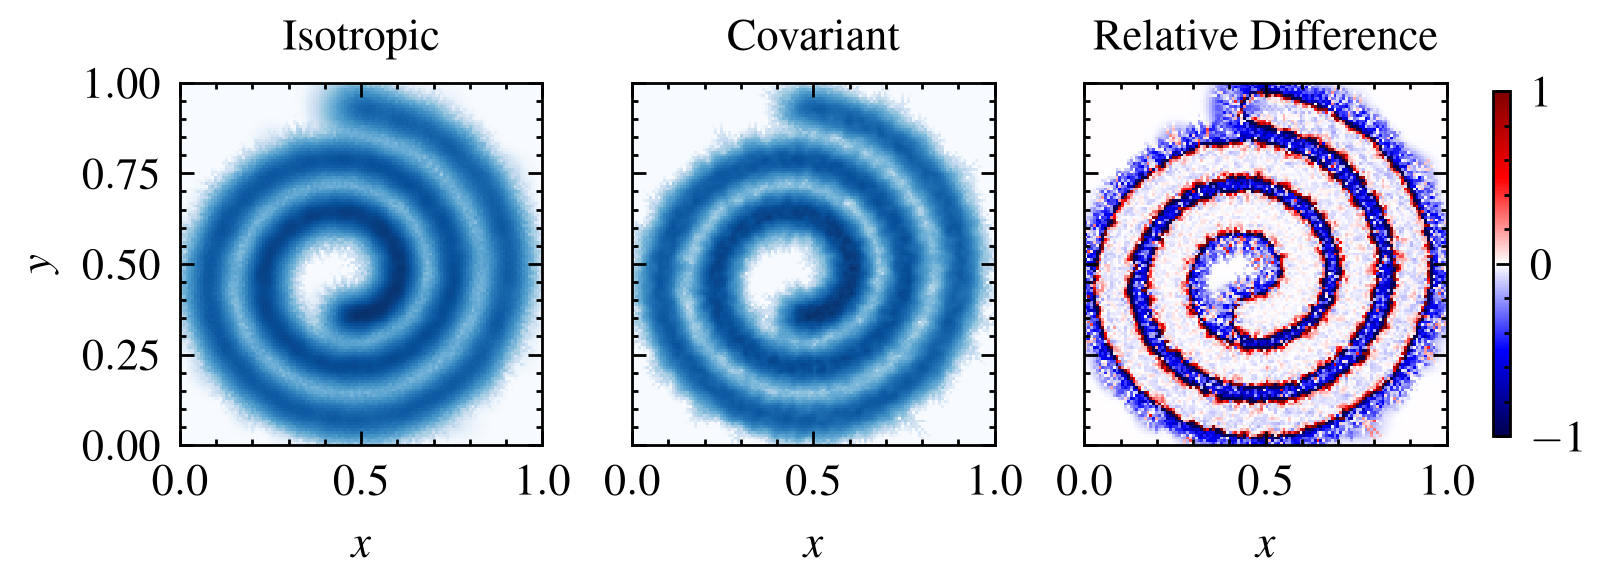

In [153]:
def relative_difference(a, b):
    return (a - b) / (b + 1e-8)

def transform_image(grid):
    # add a small value to avoid log(0)
    eps = 1e-2
    return np.log10(eps + np.rot90(grid))

grid_isotropic = transform_image(grid_isotropic)
grid_covariant = transform_image(grid_covariant)


fig, ax = plt.subplots(
    1, 3,
    figsize=(4, 2),
    sharex=True,
    sharey=True,
    constrained_layout=True,
    )
extent =[0, height, 0, height]

ax[0].imshow(grid_isotropic,
             cmap='Blues',
             interpolation='none',
             extent=extent)
ax[1].imshow(grid_covariant,
             cmap='Blues',
             interpolation='none',
             extent=extent)
im = ax[2].imshow(relative_difference(grid_isotropic, grid_covariant),
             vmin=-1, vmax=1, cmap='seismic',
             interpolation='none',
             extent=extent)

ax[0].set_title('Isotropic')
ax[1].set_title('Covariant')
ax[2].set_title('Relative Difference')

for a in ax:
    a.set_xlabel(r'$x$')
ax[0].set_ylabel(r'$y$')

fig.colorbar(im, ax=ax[2], shrink=0.45)
fig.savefig("comparison.png", dpi=500, bbox_inches="tight", transparent=False)
#plt.close()

![Comparison figure](comparison.png)

As apparent from the comparison, the `covariant` mode yields much sharper borders around the main spiral. Arguably, the `isotropic` mode gives better results outside as kernels extend over larger areas and thus yield a smoother representation of the continuous field.